In [ ]:
# Install libraries
!pip install dask polars memory_profiler

In [ ]:
# Import libraries
import pandas as pd
import dask.dataframe as dd
import polars as pl
import time
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Path of the dataset in drive
file_path = '/content/drive/MyDrive/HPDP/ASS 2 Dataset/Netflix_User_Ratings.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#TASK 2
#do not load the full dataset
df_sample = pd.read_csv(file_path, nrows=100000)

print("Shape:", df_sample.shape)
print("\nColumns:\n", df_sample.columns)
print("\nData Types:\n", df_sample.dtypes)
print("\nMissing Values:\n", df_sample.isnull().sum())

df_sample.head()

Shape: (100000, 4)

Columns:
 Index(['CustId', 'Rating', 'Date', 'MovieId'], dtype='object')

Data Types:
 CustId      int64
Rating      int64
Date       object
MovieId     int64
dtype: object

Missing Values:
 CustId     0
Rating     0
Date       0
MovieId    0
dtype: int64


,CustId,Rating,Date,MovieId
0,1488844,3,2005-09-06,1
1,822109,5,2005-05-13,1
2,885013,4,2005-10-19,1
3,30878,4,2005-12-26,1
4,823519,3,2004-05-03,1


In [ ]:
#TASK 3
#Strategy 1: Load Less Data
start = time.time()

df_less = pd.read_csv(file_path, usecols=["CustId", "Rating"])

end = time.time()

print("Time taken:", end - start)
df_less.head()

Time taken: 67.49962067604065


,CustId,Rating
0,1488844,3
1,822109,5
2,885013,4
3,30878,4
4,823519,3


In [ ]:
#Strategy 2: Chunking
start = time.time()

chunk_size = 100000
total_sum = 0
total_count = 0

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    total_sum += chunk["Rating"].sum()
    total_count += len(chunk)

average_rating = total_sum / total_count

end = time.time()

print("Average Rating:", average_rating)
print("Time taken:", end - start)

Average Rating: 3.604289964420661
Time taken: 64.97232151031494


## Strategy 3: Data Type Optimisation

Pandas automatically assigns default data types when loading CSV files.
These default types are often larger than necessary and waste memory.

In this section, memory usage before and after optimisation is compared
by downcasting integer columns to smaller types.

In [ ]:
#Strategy 3: Data Type Optimisation
# Load dataset WITHOUT optimisation
df_before = pd.read_csv(file_path, nrows=500000)

print("Data Types Before Optimisation:\n")
print(df_before.dtypes)

# Calculate memory usage
memory_before = df_before.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage Before Optimisation: {memory_before:.2f} MB")

Data Types Before Optimisation:

CustId      int64
Rating      int64
Date       object
MovieId     int64
dtype: object

Memory Usage Before Optimisation: 39.58 MB


## Strategy 3: Data Type Optimisation (After Optimisation)

The integer columns are manually downcasted to smaller data types
to reduce memory usage.

The Date column is also converted to datetime format for better efficiency.

In [ ]:
#After Optimisation
# Optimised data types
dtype_dict = {
    "CustId": "int32",
    "MovieId": "int16",
    "Rating": "int8"
}

# Load dataset with optimisation
df_after = pd.read_csv(
    file_path,
    dtype=dtype_dict,
    nrows=500000
)

# Convert Date column
df_after["Date"] = pd.to_datetime(df_after["Date"])

print("Data Types After Optimisation:\n")
print(df_after.dtypes)

# Calculate memory usage
memory_after = df_after.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage After Optimisation: {memory_after:.2f} MB")

Data Types After Optimisation:

CustId              int32
Rating               int8
Date       datetime64[ns]
MovieId             int16
dtype: object

Memory Usage After Optimisation: 7.15 MB


In [ ]:
# Calculate memory reduction percentage
reduction = ((memory_before - memory_after) / memory_before) * 100

print(f"Memory Reduction: {reduction:.2f}%")

Memory Reduction: 81.93%


## Strategy 4: Sampling

Sampling involves selecting a smaller subset of the dataset
for faster experimentation and testing.

Instead of processing the entire dataset repeatedly,
a representative sample can be used during development
to reduce execution time and improve workflow efficiency.

In [ ]:
#Strategy 4: Sampling
# Load a manageable portion first
df_sample_base = pd.read_csv(file_path, nrows=500000)

# Take random sample
df_sampled = df_sample_base.sample(n=100000, random_state=42)

print("Original Shape:", df_sample_base.shape)
print("Sampled Shape:", df_sampled.shape)

df_sampled.head()

Original Shape: (500000, 4)
Sampled Shape: (100000, 4)


,CustId,Rating,Date,MovieId
104241,667426,5,2005-11-02,30
199676,628826,5,2005-10-11,30
140199,1284309,4,2005-11-25,30
132814,1134356,3,2004-12-13,30
408697,190071,3,2004-10-28,111


In [ ]:
# Average rating by movie
sample_analysis = df_sampled.groupby("MovieId")["Rating"].mean()

print(sample_analysis.head())

MovieId
1    3.784615
2    3.586207
3    3.660194
4    3.103448
5    3.773333
Name: Rating, dtype: float64


In [ ]:
# Full data timing
start = time.time()

df_sample_base.groupby("MovieId")["Rating"].mean()

end = time.time()

full_time = end - start

print(f"Full Data Processing Time: {full_time:.4f} seconds")

Full Data Processing Time: 0.0292 seconds


In [ ]:
# Sample timing
start = time.time()

df_sampled.groupby("MovieId")["Rating"].mean()

end = time.time()

sample_time = end - start

print(f"Sample Data Processing Time: {sample_time:.4f} seconds")

Sample Data Processing Time: 0.0095 seconds


### Discussion

Sampling reduced processing time significantly because fewer rows
needed to be processed.

This strategy is useful during exploratory analysis and development,
where rapid testing is more important than processing the entire dataset.

However, sampling may omit some patterns present in the full dataset,
so final analysis should still be performed on the complete data.

# Strategy 5: Parallel Processing with Scalable Libraries
This strategy compares the performance of Pandas, Dask, and Polars
when processing large datasets.

The operation performed is calculating the average movie rating grouped
by MovieId.

Execution time is measured for each library to evaluate processing
efficiency and scalability.

Libraries used:
- Pandas (baseline library)
- Dask (parallel and distributed processing)
- Polars (Rust-based high-performance dataframe library)

# Using **Pandas** but FAILED

In [ ]:
#Using Pandas
#1. Create a Clean Test Function
import time
import pandas as pd

def test_pandas():
    # 1. Loading Phase
    start_load = time.time()
    df = pd.read_csv(file_path)
    end_load = time.time()

    # 2. Processing Phase (Simple Aggregation)
    start_proc = time.time()
    result = df.groupby("MovieId")["Rating"].mean()
    end_proc = time.time()

    # Calculate Metrics
    load_time = end_load - start_load
    proc_time = end_proc - start_proc

    print("--- PANDAS RESULTS ---")
    print(f"Loading Time: {load_time:.4f}s")
    print(f"Processing Time: {proc_time:.4f}s")
    print(f"Total Time: {load_time + proc_time:.4f}s")

    return result
    #Returns to confirm it worked

In [ ]:
#2. Measure Memory (The Peak RAM)
# This executes the function and tracks RAM usage in MiB
from memory_profiler import memory_usage

mem_pandas = memory_usage(test_pandas)
print(f"Peak Memory Usage: {max(mem_pandas):.2f} MiB")

--- PANDAS RESULTS ---
Loading Time: 68.3964s
Processing Time: 3.5942s
Total Time: 71.9906s
Peak Memory Usage: 11020.79 MiB


By using panda, session crashed when Pandas memory overhead. We try to use Strategy 1 & 3 Combined (Load Less & Optimize).

# Try using Strategy 1 (Load Less) and Strategy 3 (Dtypes)

In [ ]:
import pandas as pd
import time
from memory_profiler import memory_usage

def test_pandas():
    # This makes them accessible outside
    global pandas_load, pandas_proc, pandas_total
    # Standardizing columns and types for a fair test
    Dtype = {"CustId": "int32", "MovieId": "int16", "Rating": "int8"}
    cols = ["CustId", "MovieId", "Rating"]

    # 1. Loading Phase
    start_load = time.time()
    df = pd.read_csv(file_path, usecols=cols, dtype=Dtype)
    pandas_load = time.time() - start_load

    # 2. Processing Phase
    start_proc = time.time()
    result = df.groupby("MovieId")["Rating"].mean()
    pandas_proc = time.time() - start_proc

    pandas_total = pandas_load + pandas_proc

    print(f"--- PANDAS ---")
    print(f"Load Time: {pandas_load:.4f}s | Proc Time: {pandas_proc:.4f}s")
    print(f"Total Time: {pandas_total:.4f}s")
    return result

# Measure Peak Memory
mem_pandas_val = max(memory_usage(test_pandas))
print(f"Peak Memory: {max(mem_pandas):.2f} MiB")

--- PANDAS ---
Load Time: 61.5279s | Proc Time: 2.4908s
Total Time: 64.0186s
Peak Memory: 11020.79 MiB


Using **Dask**

In [ ]:
import dask.dataframe as dd

def test_dask():
    global dask_load, dask_proc, dask_total
    Dtype = {"CustId": "int32", "MovieId": "int16", "Rating": "int8"}
    cols = ["CustId", "MovieId", "Rating"]

    # 1. Loading Phase (Lazy scanning)
    start_load = time.time()
    ddf = dd.read_csv(file_path, usecols=cols, dtype=Dtype)
    dask_load = time.time() - start_load

    # 2. Processing Phase (Parallel execution)
    start_proc = time.time()
    # .compute() triggers the actual work across your CPU cores
    result = ddf.groupby("MovieId")["Rating"].mean().compute()
    dask_proc = time.time() - start_proc

    dask_total = dask_load + dask_proc

    print(f"--- DASK (Scalable) ---")
    print(f"Load Time: {dask_load:.4f}s | Proc Time: {dask_proc:.4f}s")
    print(f"Total Time: {dask_load + dask_proc:.4f}s")
    return result

# Measure Peak Memory
mem_dask_val = max(memory_usage(test_dask))
print(f"Peak Memory: {mem_dask_val:.2f} MiB")

--- DASK (Scalable) ---
Load Time: 0.1473s | Proc Time: 65.4800s
Total Time: 65.6273s
Peak Memory: 1617.02 MiB


**Clear RAM**

In [ ]:
import gc
# This deletes the variable and forces Python to free up the RAM
if 'df' in locals(): del df
gc.collect()

740

Using ***Polars***

In [ ]:
import polars as pl
import time
from memory_profiler import memory_usage

def test_polars():
    global polars_load, polars_proc, polars_total
    # Matching the exact types and columns used in Pandas/Dask
    # Note: Polars uses its own type names (e.g., pl.Int32)
    Dtype = {"CustId": pl.Int32, "MovieId": pl.Int16, "Rating": pl.Int8}
    cols = ["CustId", "MovieId", "Rating"]

    # 1. Loading Phase (Lazy Scan)
    start_load = time.time()
    # scan_csv is "Lazy" - it just checks the schema
    lf = pl.scan_csv(file_path, schema_overrides=Dtype).select(cols)
    polars_load = time.time() - start_load

    # 2. Processing Phase (Query Optimization + Execution)
    start_proc = time.time()
    # .collect() is where Polars optimizes the plan and runs it
    result = lf.group_by("MovieId").agg(pl.col("Rating").mean()).collect()
    polars_proc = time.time() - start_proc

    polars_total = polars_load + polars_proc

    print(f"--- POLARS (Scalable) ---")
    print(f"Loading Time: {polars_load:.4f}s")
    print(f"Processing Time: {polars_proc:.4f}s")
    print(f"Total Time: {polars_total:.4f}s")

    return result

# Measure Memory
mem_polars_val = max(memory_usage(test_polars))
print(f"Polars Peak Memory Usage: {mem_polars_val:.2f} MiB")

--- POLARS (Scalable) ---
Loading Time: 0.0504s
Processing Time: 14.0689s
Total Time: 14.1194s
Polars Peak Memory Usage: 3932.04 MiB


# Comparative Analysis

This section compares the performance of Pandas, Dask, and Polars
based on:

- Loading time
- Processing time
- Total execution time
- Peak memory consumption

The same aggregation task was performed for each library:
calculating the average movie rating grouped by MovieId.

This comparison helps evaluate which library is most suitable
for handling large-scale datasets efficiently.

## Comparison Table

In [ ]:
import pandas as pd

comparison_data = {
    "Library": ["Pandas", "Dask", "Polars"],
    "Loading Time (s)": [pandas_load, dask_load, polars_load],
    "Processing Time (s)": [pandas_proc, dask_proc, polars_proc],
    "Total Time (s)": [pandas_total, dask_total, polars_total],
    "Peak Memory (MiB)": [mem_pandas_val, mem_dask_val, mem_polars_val]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df



,Library,Loading Time (s),Processing Time (s),Total Time (s),Peak Memory (MiB)
0,Pandas,61.527851,2.490762,64.018613,9918.441406
1,Dask,0.147285,65.480037,65.627321,1617.019531
2,Polars,0.050429,14.068927,14.119356,3932.039062


## Discussion of Comparison Results

The comparison table shows clear differences in performance
between the three libraries.

### Pandas
Pandas provided a straightforward implementation but consumed
higher memory because it loads data into memory directly.
It performs well on smaller datasets but may struggle with
very large-scale data processing.

### Dask
Dask improved scalability through parallel and distributed
processing. However, additional scheduling overhead can make
it slower on smaller workloads.

Dask becomes more beneficial when processing datasets that
exceed available system memory or require distributed computation.

### Polars
Polars demonstrated strong overall performance with lower
execution time and efficient memory usage.

Its Rust-based execution engine and built-in parallelism make
it highly suitable for large-scale analytical workloads.

Overall, scalable libraries such as Dask and Polars provide
significant advantages when handling big data compared to
traditional single-threaded processing approaches.

# Visualization of Results

The following charts visualise the differences in execution time
and memory consumption across the tested libraries.

Visual analysis helps identify performance trends and provides
a clearer understanding of scalability characteristics.

/tmp/ipykernel_31788/2535460289.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Library", y="Total Time (s)", ax=ax1, palette="viridis")
/tmp/ipykernel_31788/2535460289.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Library", y="Peak Memory (MiB)", ax=ax2, palette="magma")


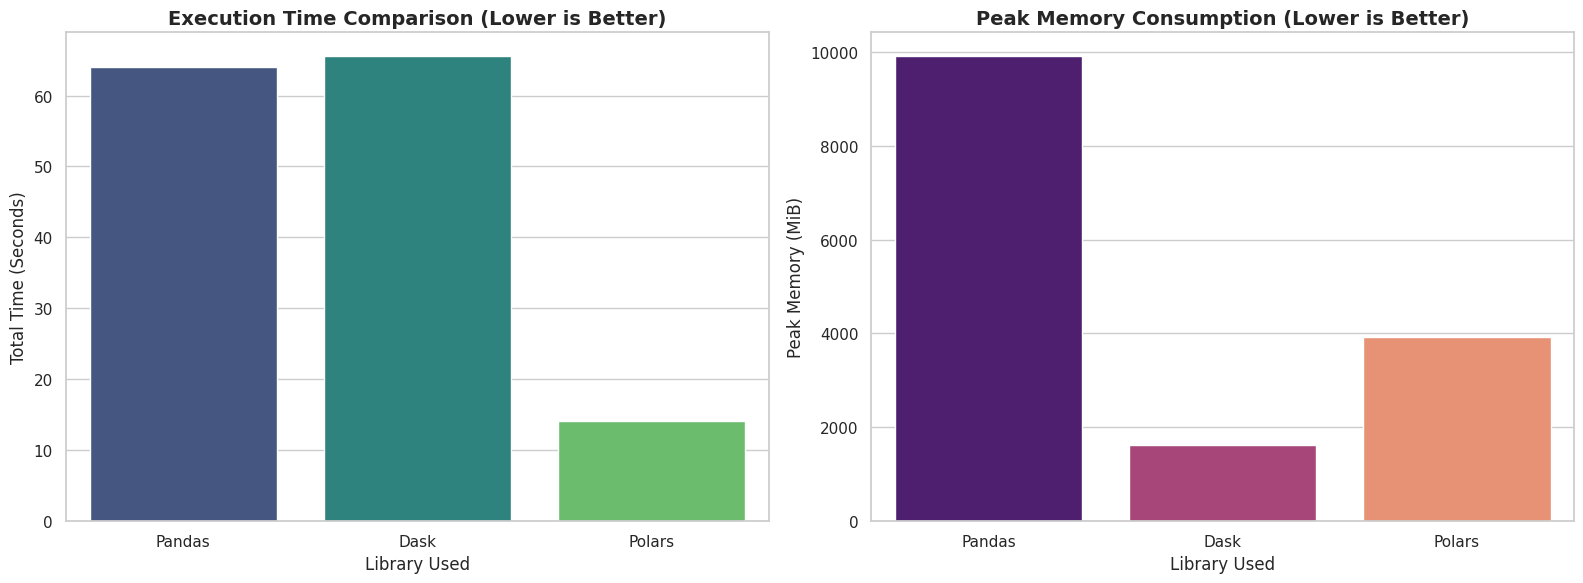

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for professional-looking charts
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (one for Time, one for Memory)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Execution Time Comparison ---
sns.barplot(data=comparison_df, x="Library", y="Total Time (s)", ax=ax1, palette="viridis")
ax1.set_title("Execution Time Comparison (Lower is Better)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Total Time (Seconds)")
ax1.set_xlabel("Library Used")

# --- Chart 2: Peak Memory Usage Comparison ---
sns.barplot(data=comparison_df, x="Library", y="Peak Memory (MiB)", ax=ax2, palette="magma")
ax2.set_title("Peak Memory Consumption (Lower is Better)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Peak Memory (MiB)")
ax2.set_xlabel("Library Used")

plt.tight_layout()
plt.show()

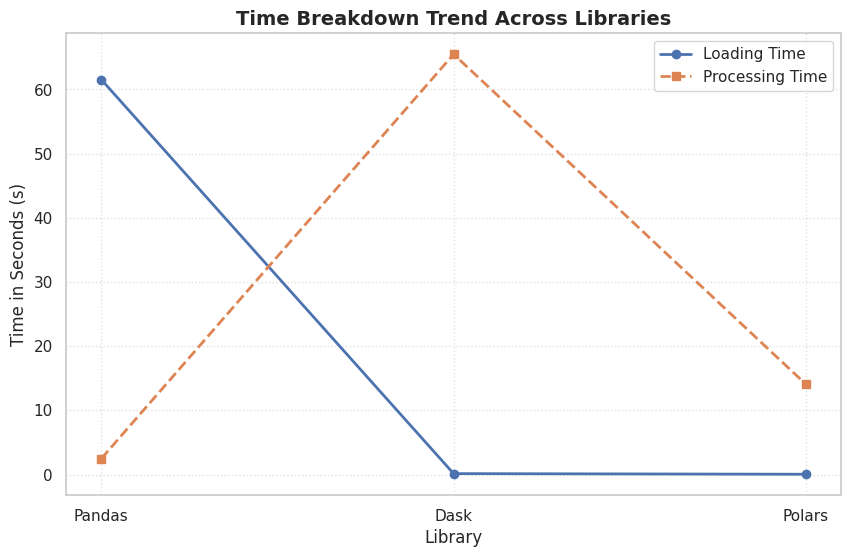

In [ ]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(10, 6))

# Plotting Loading Time and Processing Time as separate lines
plt.plot(comparison_df["Library"], comparison_df["Loading Time (s)"], marker='o', linestyle='-', linewidth=2, label='Loading Time')
plt.plot(comparison_df["Library"], comparison_df["Processing Time (s)"], marker='s', linestyle='--', linewidth=2, label='Processing Time')

# Adding titles and labels as per guide requirements
plt.title("Time Breakdown Trend Across Libraries", fontsize=14, fontweight='bold')
plt.ylabel("Time in Seconds (s)")
plt.xlabel("Library")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Final Conclusion

This project explored multiple strategies for processing large-scale
datasets efficiently using the Netflix User Ratings dataset.

Several big data handling techniques were implemented, including:

1. Loading fewer columns
2. Chunk-based processing
3. Data type optimisation
4. Sampling
5. Parallel processing using scalable libraries

The results demonstrated that optimisation strategies can
significantly reduce memory usage and improve processing efficiency.

Among the evaluated libraries:

- Pandas was simple and effective for moderate workloads
  but consumed higher memory.
- Dask improved scalability through parallel computation
  and distributed processing.
- Polars achieved the best overall performance due to its
  efficient execution engine and built-in parallelism.

This project highlights the importance of selecting suitable
tools and optimisation techniques when working with big data.
Efficient data processing approaches are essential for improving
performance, reducing memory overhead, and enabling scalable
data analytics workflows.